<a href="https://colab.research.google.com/github/Avadhi-Singhal/MachineLearning/blob/UnsupervisedMLAlgorithms/K_MeanClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
%matplotlib inline

In [3]:
x,y = make_blobs(n_samples=1000,centers=3,n_features=2)

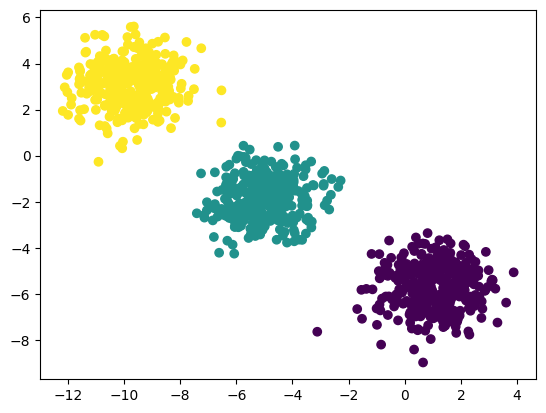

In [4]:
plt.scatter(x[:,0],x[:,1],c=y)

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42
)

In [7]:
## Standardization ---> feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [8]:
from sklearn.cluster import KMeans

In [11]:
## Elbow Method to Select K Value
wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(x_train_scaled)
  wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

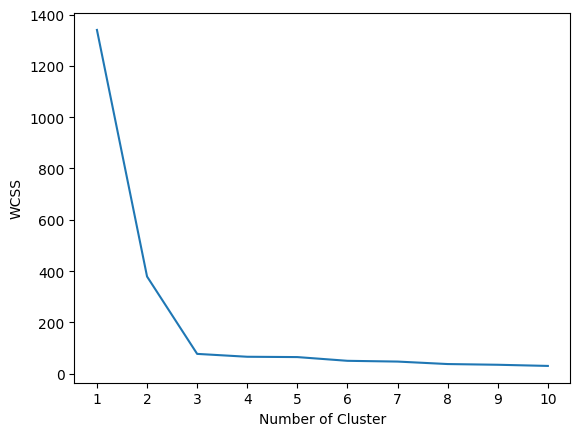

In [12]:
## plot Elbow Curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Cluster")
plt.ylabel("WCSS")

In [13]:
kmeans = KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(x_train_scaled)

array([2, 1, 1, 2, 0, 0, 1, 2, 0, 2, 2, 2, 2, 1, 0, 2, 2, 2, 0, 0, 0, 0,
       0, 2, 2, 0, 2, 2, 2, 1, 1, 0, 1, 1, 1, 0, 1, 1, 2, 2, 1, 0, 2, 2,
       1, 2, 1, 2, 0, 0, 0, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 0, 1, 1, 0,
       1, 0, 2, 0, 2, 2, 2, 1, 0, 2, 0, 1, 0, 0, 0, 2, 2, 1, 2, 2, 1, 1,
       1, 1, 2, 1, 0, 2, 2, 1, 2, 1, 0, 1, 1, 0, 0, 1, 0, 1, 2, 2, 1, 2,
       2, 2, 1, 1, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 1, 1, 0, 2, 2, 0, 1, 2,
       0, 0, 2, 0, 1, 1, 1, 1, 2, 0, 1, 0, 2, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       2, 0, 0, 0, 1, 2, 1, 2, 0, 0, 1, 1, 1, 1, 0, 0, 0, 2, 2, 0, 1, 0,
       1, 1, 2, 0, 2, 0, 1, 2, 1, 0, 2, 0, 0, 0, 1, 0, 0, 2, 0, 2, 0, 1,
       0, 2, 1, 2, 2, 2, 0, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 0, 0, 0, 1, 2,
       1, 1, 0, 2, 2, 0, 0, 2, 0, 0, 0, 2, 1, 0, 2, 1, 2, 1, 1, 1, 0, 2,
       2, 1, 2, 1, 1, 2, 0, 2, 0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       2, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 0, 0, 0, 0, 0, 2, 1, 1, 2, 1,
       0, 1, 2, 1, 1, 2, 1, 2, 1, 1, 2, 0, 2, 0, 0,

In [14]:
y_pred = kmeans.predict(x_test_scaled)

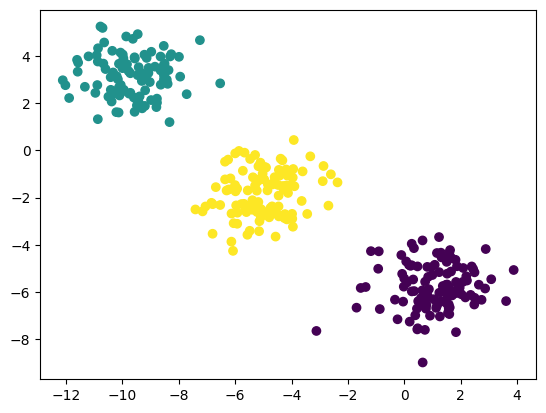

In [16]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)

In [21]:
## Validating the k value
## Kneelocator
## Silhouette Scoring

In [18]:
## Kneelocator
!pip install kneed

In [20]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

3

In [23]:
## Silhouette Score
from sklearn.metrics import silhouette_score
silhouette_coefficients = []
for k in range(2,11):
  kmeans = KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(x_train_scaled)
  score = silhouette_score(x_train_scaled,kmeans.labels_)
  silhouette_coefficients.append(score)

silhouette_coefficients

[0.6259040073241563,
 0.7363416856369834,
 0.614650214029506,
 0.47388828688730567,
 0.35032678773207165,
 0.34473977864726346,
 0.36226919276434977,
 0.3366164524480602,
 0.3410337667317006]

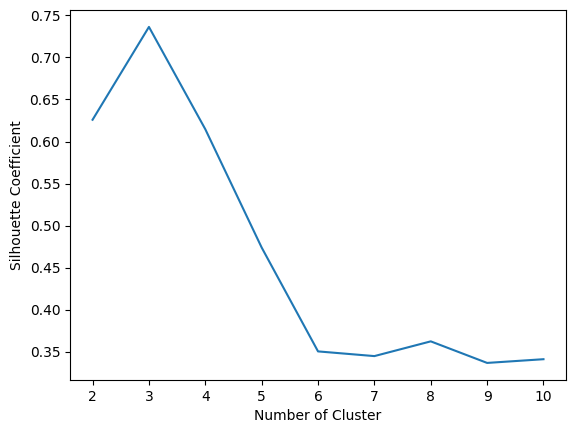

In [24]:
## Plotting Silhouette Score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluster")
plt.ylabel("Silhouette Coefficient")
plt.show()